In [47]:
import numpy as np
import sympy as sp
from scipy.linalg import eigh, inv, pinvh
from scipy.special import gamma, kv

In [48]:
def cartdist(x1,y1,x2,y2,xmax,ymax):
    """cartesian distance on doubly periodic plane"""
    dx = np.abs(x1 - x2)
    dy = np.abs(y1 - y2)
    dx = np.where(dx > 0.5*xmax, xmax - dx, dx)
    dy = np.where(dy > 0.5*ymax, ymax - dy, dy)
    return np.sqrt(dx**2 + dy**2)

def gasp_cohn(r):
    """
    Gaspari-Cohn taper function.
    very close to exp(-(r/c)**2), where c = sqrt(0.15)
    r should be >0 and normalized so taper = 0 at r = 1
    """
    rr = 2.*r
    rr += 1.e-13 # avoid divide by zero warnings from numpy
    taper = np.where(r<=0.5, \
            ( ( ( -0.25*rr +0.5 )*rr +0.625 )*rr -5.0/3.0 )*rr**2 + 1.0,\
            np.zeros(r.shape,r.dtype))
    taper = np.where(np.logical_and(r>0.5,r<1.), \
            ( ( ( ( rr/12.0 -0.5 )*rr +0.625 )*rr +5.0/3.0 )*rr -5.0 )*rr \
               + 4.0 - 2.0 / (3.0 * rr), taper)
    return taper

def generalized_normal(r, beta):
    # https://en.wikipedia.org/wiki/Generalized_normal_distribution
    # beta=1 is exponential (laplace), beta=2 is gaussian.
    if beta < 1 or beta > 2:
        raise ValueError('1 <= beta <= 2 for generalized normal')
    return np.exp(-r**beta)

def rq(r, alpha):
    # rational quadratic cov function.
    # equivalent to a sum of gaussians with different length scales
    # length scale (l) parameter = 0.5
    return (1+r**2/alpha)**-alpha

def matern(r,v,l=1):
    # matern covariance function (v=0.5 is exponential, v->inf is gaussian)
    # overflow will result for values of v greater than about 35
    r[r == 0] = 1e-8
    part1 = 2 ** (1 - v) / gamma(v)
    part2 = (np.sqrt(2 * v) * r / l) ** v
    part3 = kv(v, np.sqrt(2 * v) * r / l)
    return part1 * part2 * part3

def get_grid_dimensions_(Lx=None, Ly=None, nx=None, ny=None, ndim=None):
    """
    Calculate grid dimensions mx and my based on given parameters.
    
    Parameters:
    Lx (float): Length in x-direction
    Ly (float): Length in y-direction
    nx (int): Number of elements in x-direction
    ny (int): Number of elements in y-direction
    ndim (int): Total number of grid points (mx * my)
    
    Returns:
    tuple: (mx, my) - number of grid points in x and y directions
    """
    
    # Define symbolic variables
    mx, my = sp.symbols('mx, my')
    
    # Calculate aspect ratio from elemnet ratio: nx/ny
    if nx is not None and ny is not None:
        alpha = nx / ny
    elif Lx is not None and Ly is not None:
        alpha = Lx / Ly
    
    # Set up equations
    eqn1 = sp.Eq(mx/my, alpha)  # aspect ratio equation
    eqn2 = sp.Eq(mx*my, ndim)   # total points equation
    
    # Solve the system of equations
    sol = sp.solve([eqn1, eqn2], (mx, my))
    sol1, sol2 = sol[0], sol[1]
    
    # Choose the positive solution
    mx, my = sol1 if sol1[0] > 0 else sol2
    
    # Round based on decimal values
    if mx - int(mx) > 0.5:
        mx = int(np.ceil(mx))
        my = int(np.floor(my))
    elif my - int(my) > 0.5:
        my = int(np.ceil(my))
        mx = int(np.floor(mx))
    else:
        mx, my = int(mx), int(my)
    
    # Adjust mx and my to exactly match ndim while preserving aspect ratio
    if mx * my != ndim:
        # Calculate scaling factor
        scale_factor = (ndim / (mx * my)) ** 0.5
        
        # Initial adjustment
        mx_new = int(round(mx * scale_factor))
        my_new = int(round(my * scale_factor))
        
        # Fine-tune to exactly match ndim
        while mx_new * my_new != ndim:
            if mx_new * my_new < ndim:
                # Increment smaller dimension relative to aspect ratio
                if mx_new/my_new < alpha:
                    mx_new += 1
                else:
                    my_new += 1
            else:
                # Decrement larger dimension relative to aspect ratio
                if mx_new/my_new > alpha:
                    mx_new -= 1
                else:
                    my_new -= 1
        
        mx, my = mx_new, my_new
    
    return mx, my

def get_grid_dimensions(Lx, Ly, ndim):
    """
    Calculate grid dimensions mx and my based on physical dimensions and total points.
    
    Parameters:
    Lx (float): Length in x-direction
    Ly (float): Length in y-direction
    ndim (int): Total number of grid points (mx * my)
    
    Returns:
    tuple: (mx, my) - number of grid points in x and y directions
    """
    # Calculate aspect ratio from physical dimensions
    alpha = Lx / Ly
    
    # Initial estimate based on aspect ratio and ndim
    # mx/my = alpha and mx*my = ndim
    # mx = sqrt(ndim * alpha), my = sqrt(ndim / alpha)
    mx = np.sqrt(ndim * alpha)
    my = np.sqrt(ndim / alpha)
    
    # Initial rounding
    if mx - int(mx) > 0.5:
        mx = int(np.ceil(mx))
        my = int(np.floor(my))
    elif my - int(my) > 0.5:
        my = int(np.ceil(my))
        mx = int(np.floor(mx))
    else:
        mx, my = int(mx), int(my)
    
    # Quick adjustment to reach ndim
    current_product = mx * my
    if current_product != ndim:
        # Calculate scale factor
        scale = np.sqrt(ndim / current_product)
        mx = int(round(mx * scale))
        my = int(round(my * scale))
        
        # Fast fine-tuning with minimal iterations
        product = mx * my
        if product < ndim:
            while product < ndim:
                if mx/my < alpha:
                    mx += 1
                else:
                    my += 1
                product = mx * my
        elif product > ndim:
            while product > ndim:
                if mx/my > alpha:
                    mx -= 1
                else:
                    my -= 1
                product = mx * my
    
    return mx, my



In [84]:

# Example usage with your specific values
Lx, Ly = 50e2, 12e2
nx, ny = 12, 8
ndim = 425

mx, my = get_grid_dimensions(nx, ny, ndim)
print(f"Grid dimensions: mx = {mx}, my = {my}")
print(f"Verification: mx * my = {mx * my} (should equal {ndim})")

verbose = 1
localsolve = 1 # local analysis for B loc
lscale = 5 # localization scale in grid points
oberrvar = 0.1 # observation error variance
covscale = 0.1 # covariance scale as a fraction of domain size
scale = ndim*covscale
cov_param = 1.5 # covariance parameter
nsamples =10 # ensemble members
ntrials = 100 # number of trials


Grid dimensions: mx = 25, my = 17
Verification: mx * my = 425 (should equal 425)


In [85]:
# localization matrices
local = np.zeros((mx*my,mx*my))
cov = np.zeros((mx*my,mx*my))
yg,xg = np.unravel_index(np.arange(mx*my),(my,mx)) # grid indices
nmid = ndim//2+mx//2 # index of the middle of the grid
for i in range(mx*my):
    dist = cartdist(xg,yg,xg[i],yg[i],mx,my)
    local[:,i] = gasp_cohn(dist/lscale)
    cov[:,i] = matern(dist/scale,cov_param)
    i +=1

# optimal gain matrix
Rm = oberrvar * np.eye(ndim)
kfopt = np.dot(cov, inv(cov + Rm))
paopt = np.dot((np.eye(ndim) - kfopt), cov)
if verbose:
    print('tr(pa)/tr(pb) = ',np.trace(paopt)/np.trace(cov))
kfopt_frobnorm = (kfopt**2).sum()

# compute eigrnanalysis of true covariance matrix to sample
evals,evecs = eigh(cov)


if verbose:
    for i in range(1,ndim):
        percentvar = evals[-i:].sum()/evals.sum()
        if percentvar < 0.99:
            nrank = i
            break
    print('rank of covariance matrix = ',nrank)

evals = evals.clip(min=np.finfo(evals.dtype).eps)
scaled_evals = np.dot(evecs, np.diag(np.sqrt(evals)))/np.sqrt(nsamples-1)

# run trials with different ensembles
if verbose:
    kfensmean_bloc = np.zeros((ndim,ndim))
    kfensmean_rloc = np.zeros((ndim,ndim))

meankferr_bloc = 0
meankferr_rloc = 0
nlocal = 0; neig = 0
for ntrial in range(ntrials):
    # generate ensemble (x is an array of unit normal random numbers)
    x = np.random.normal(size=(ndim,nsamples))
    x = x - x.mean(axis=1)[:,np.newaxis] # zero mean
    y = np.dot(scaled_evals,x) # scale by eigenvalues

    # compute Kalman gain for global soltion with B loc
    if not localsolve:
        cov_Samples = local*np.dot(y,y.T)
        kfens_bloc = np.dot(cov_Samples, inv(cov_Samples + Rm))
    else: 
        kfens_bloc = np.zeros((ndim,ndim))

    # compute local solution for R loc
    kfens_rloc = np.zeros((ndim,ndim))
    for i in range(ndim):
        # find local grid points (obs since H = I)
        dist = cartdist(xg,yg,xg[i],yg[i],mx,my)
        indx = dist < np.abs(lscale)   
        nmindist = np.argmin(dist[indx]) # index of minimum distance
        ylocal = y[np.ix_(indx, np.ones(nsamples,dtype=bool))].T

        # traditional R localization
        if not localsolve:
            YbRinv  = ylocal*local[indx,i]/oberrvar
            pa = np.eye(nsamples) + np.dot(YbRinv,ylocal.T)
            kfens_rloc[indx,i] = np.dot(y[i,:], np.dot(inv(pa), YbRinv))
        else:
            #  R localization achieved by tapering ens parts 
            # Sakov DOI 10.1007/s10596-010-9202-6)
            taper = np.sqrt(local[indx,i])
            ylacalloc = ylocal*taper # depends on distance between obs and analysis point
            YbRinv = ylacalloc/oberrvar
            pa = np.eye(nsamples) + np.dot(YbRinv,ylacalloc.T)
            kfens_rloc[indx,i] = taper*np.dot(y[i,:], np.dot(inv(pa), YbRinv))

            # B loc modulate ensemble with eigenvectors of 'local' localiztion matrix
            if not ntrial: 
                # compute and save modulation vectors
                localloc = local[np.ix_(indx,indx)] 
                if not nlocal: nlocal = localloc.shape[0]
                nlocal2 = localloc.shape[0]
                if nlocal != nlocal2:
                    raise ValueError('nlocal not constant')
                # symmetric square root of localization (truncated eigenvector expansion)
                evals,evecs = eigh(localloc)
                for nn in range (1,nlocal):
                    percentvar = evals[-nn:].sum()/evals.sum()
                    if percentvar > 0.99:
                        neigcount = nn
                        break
                if not neig: neig = neigcount
                if neigcount != neig:
                    raise ValueError('neig not constant')
                evecs_norm = (evecs*np.sqrt(evals/percentvar)).T
                if not i:
                    sqrtlocalloc = np.zeros((ndim,neig,nlocal))
                sqrtlocalloc[i,:,:] = evecs_norm[nlocal-neig:nlocal,:]
                ylocal2 = np.multiply(np.repeat(sqrtlocalloc[i],nsamples,axis=0),np.tile(ylocal,(neig,1)))
                YbRinv = ylocal2/oberrvar
                pa = np.eye(neig*nsamples) + np.dot(YbRinv,ylocal2.T)
                kfens_bloc[indx,i] = np.dot(ylocal2[:,nmindist], np.dot(inv(pa), YbRinv))

    # normalized Frobenius norm 
    if verbose:
        kfensmean_rloc += kfens_rloc/ntrials
        kfensmean_bloc += kfens_bloc/ntrials
    
    diff_rloc = kfens_rloc - kfopt
    diff_bloc = kfens_bloc - kfopt
    kferr_rloc = (diff_rloc**2).sum()
    kferr_bloc = (diff_bloc**2).sum()
    meankferr_rloc += (kferr_rloc/kfopt_frobnorm)/ntrials
    meankferr_bloc += (kferr_bloc/kfopt_frobnorm)/ntrials

tr(pa)/tr(pb) =  0.004388209203811107
rank of covariance matrix =  1


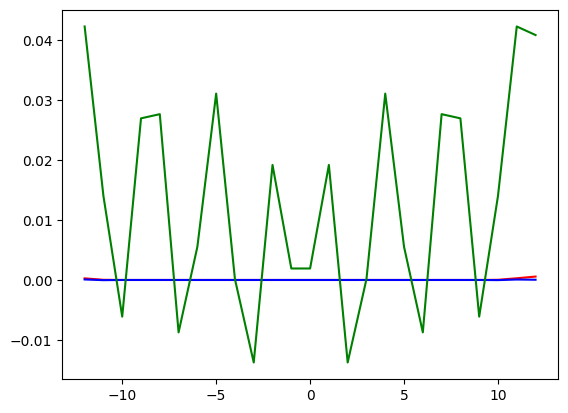

In [87]:
import matplotlib.pyplot as plt
plt.figure()
nlocal = 2*int(lscale) -1
x = np.arange(mx) - mx//2
x2 = np.linspace(mx//2-nlocal//2,mx//2+nlocal//2,nlocal) - mx//2
kfrloc = kfensmean_rloc[nmid].reshape((my,mx))
kfbloc = kfensmean_bloc[nmid].reshape((my,mx))
kfopt2d = kfopt[nmid].reshape((my,mx))
plt.plot(x,kfrloc[mx//2],'r',label='K rloc')
plt.plot(x,kfbloc[mx//2],'b',label='K bloc')
plt.plot(x,kfopt2d[mx//2],'g',label='K true')

In [89]:
local = np.zeros((mx*my,mx*my))
yg,xg = np.unravel_index(np.arange(mx*my),(my,mx)) # grid indices
nmid = ndim//2+mx//2 # index of the middle of the grid
for i in range(mx*my):
    dist = cartdist(xg,yg,xg[i],yg[i],mx,my)
    local[:,i] = gasp_cohn(dist/lscale)
    i +=1

In [ ]:
kfens_rloc = np.zeros((ndim,ndim))
kfensmean_rloc = np.zeros( (ndim,ndim) )
for n in range(ndim):
    #  find local grid points (obs since H = I)
    dist = cartdist(xg,yg,xg[n],yg[n],mx,my)
    indx = dist < np.abs(lscale)
    nmindist = np.argmin(dist[indx]) # index of minimum distance
    ylocal = y[np.ix_(indx, np.ones(nsamples,dtype=bool))].T